# Disaster Tweets Classification — MSIT NLP Project

**Goal**: Build a model that predicts whether a tweet is about a **real disaster** (1) or **not** (0). This project is part of MSIT Data Science coursework.

**Why this matters**: During emergencies, people tweet about disasters in real-time. If we can automatically identify which tweets are about real disasters, emergency services can respond faster.

**Dataset**: Kaggle's "Natural Language Processing with Disaster Tweets" (~7,600 tweets, each labeled disaster or not)

**Our Approach**:
1. Load & explore the data
2. Clean and preprocess the text
3. Lemmatize with POS tags
4. Remove stop words + custom stop words
5. Vectorize with TF-IDF (using Pipeline)
6. Train 3 models: Logistic Regression, SVM, Random Forest
7. Evaluate using F1 score as primary metric
8. Compare prediction probabilities across models
9. Cross-validate for reliable results

### Step 1: Setup & Data Loading

We start by mounting Google Drive to access our CSV file, then import all the libraries we need for the project.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from collections import Counter

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [3]:
train_df = pd.read_csv('/content/drive/MyDrive/train.csv')

print(f"Dataset shape: {train_df.shape}")
print(f"Column names: {list(train_df.columns)}")
train_df.head()

Dataset shape: (7613, 2)
Column names: ['text', 'target']


,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


We loaded 7,613 tweets with 2 columns: `text` and `target`. The first few rows show disaster tweets (target=1) about earthquakes, forest fires, and evacuations.

---

### Step 2: Exploratory Data Analysis (EDA)

Before modeling, we check for missing values, class balance, and tweet characteristics.

In [4]:
print("=== Missing Values ===")
print(train_df.isnull().sum())

=== Missing Values ===
text      0
target    0
dtype: int64


> **Insight:** Zero missing values in both columns — our data is clean and complete. No need for imputation or dropping rows.

=== Class Distribution ===
target
0    4342
1    3271
Name: count, dtype: int64

Percentage:
target
0    57.0
1    43.0
Name: proportion, dtype: float64


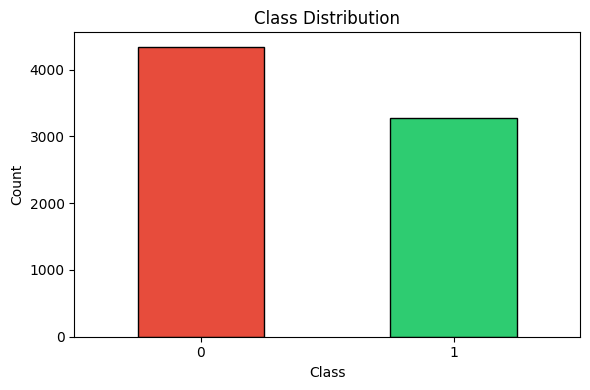

In [5]:
print("=== Class Distribution ===")
print(train_df['target'].value_counts())
print(f"\nPercentage:")
print(train_df['target'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(6, 4))
train_df['target'].value_counts().plot(
    kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> **Insight:** The dataset has 4,342 non-disaster tweets (57%) and 3,271 disaster tweets (43%). This is a slight imbalance. Two consequences:
> 1. We use **stratify** in train-test split to preserve this ratio in both sets
> 2. We use **F1 score** instead of accuracy — because a model that always predicts "non-disaster" would get 57% accuracy without learning anything


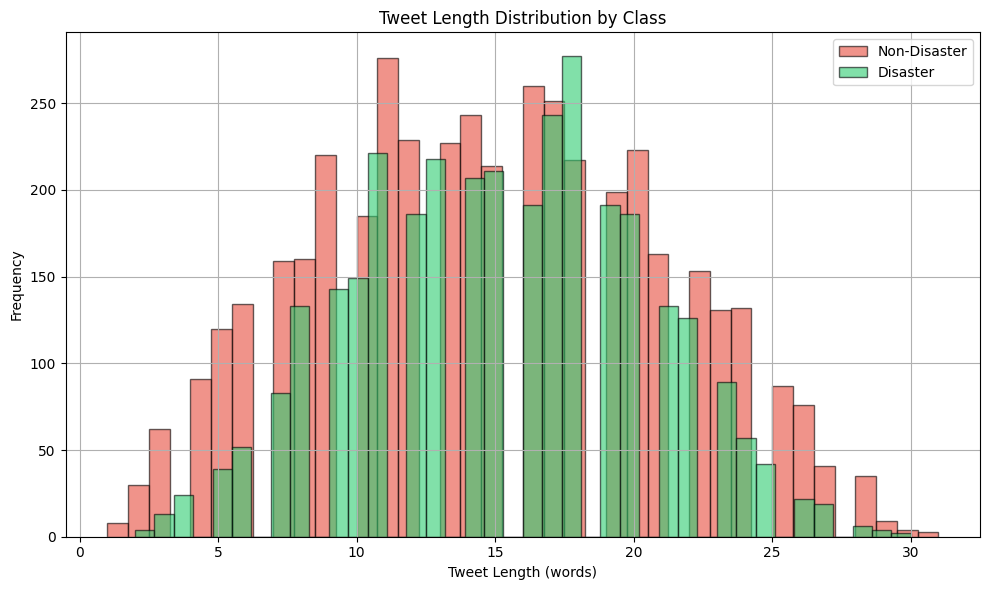

Avg Non-Disaster: 14.7 words
Avg Disaster: 15.2 words


In [6]:
train_df['tweet_length'] = train_df['text'].apply(
    lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
train_df[train_df['target']==0]['tweet_length'].hist(
    bins=40, alpha=0.6, label='Non-Disaster',
    color='#e74c3c', edgecolor='black')
train_df[train_df['target']==1]['tweet_length'].hist(
    bins=40, alpha=0.6, label='Disaster',
    color='#2ecc71', edgecolor='black')
plt.xlabel('Tweet Length (words)')
plt.ylabel('Frequency')
plt.title('Tweet Length Distribution by Class')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Avg Non-Disaster: {train_df[train_df['target']==0]['tweet_length'].mean():.1f} words")
print(f"Avg Disaster: {train_df[train_df['target']==1]['tweet_length'].mean():.1f} words")

> **Insight:** Both classes have similar tweet length distributions, with most tweets between 10-25 words. Disaster tweets tend to be slightly longer on average — people provide more detail when reporting real emergencies. This tells us tweet length alone won't be a strong classifier; we need the actual word content.

In [7]:
print("=== Sample DISASTER tweets ===")
print()
for i, row in train_df[train_df['target']==1].head(3).iterrows():
    print(f"  -> {row['text']}")
    print()

print("=== Sample NON-DISASTER tweets ===")
print()
for i, row in train_df[train_df['target']==0].head(3).iterrows():
    print(f"  -> {row['text']}")
    print()

=== Sample DISASTER tweets ===

  -> Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

  -> Forest fire near La Ronge Sask. Canada

  -> All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected

=== Sample NON-DISASTER tweets ===

  -> What's up man?

  -> I love fruits

  -> Summer is lovely



> **Insight:** Looking at real examples reveals the challenge. Disaster tweets mention earthquakes, forest fires, and evacuations with specific details. Non-disaster tweets are casual ("What's up man?", "I love fruits"). The tricky part is tweets that use disaster words metaphorically — "my career is on fire" or "that exam destroyed me" — our model needs to learn the difference.

---

### Step 3: Text Preprocessing

Tweets are messy — URLs, @mentions, hashtags, emojis. We clean all of this because it's noise, not signal. Our cleaning pipeline: remove URLs, remove @mentions, remove # symbol (keep the word), lowercase, remove numbers, remove special characters.

In [8]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '',
                  text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)

print("=== Before vs After Cleaning ===")
print()
for i in range(3):
    print(f"BEFORE: {train_df['text'].iloc[i]}")
    print(f"AFTER:  {train_df['clean_text'].iloc[i]}")
    print()

=== Before vs After Cleaning ===

BEFORE: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
AFTER:  our deeds are the reason of this earthquake may allah forgive us all

BEFORE: Forest fire near La Ronge Sask. Canada
AFTER:  forest fire near la ronge sask canada

BEFORE: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
AFTER:  all residents asked to shelter in place are being notified by officers no other evacuation or shelter in place orders are expected



> **Insight:** How the cleaning works:
> - `#earthquake` became `earthquake` — kept the useful word, removed the symbol
> - `Sask.` became `sask` — removed the period, lowercased
> - `'shelter in place'` became `shelter in place` — removed quotes
> - Numbers like `13,000` were removed — they don't help TF-IDF classify text


In [9]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return 'a'
    elif tag.startswith('V'):
        return 'v'
    elif tag.startswith('N'):
        return 'n'
    elif tag.startswith('R'):
        return 'r'
    else:
        return 'n'

stop_words = set(stopwords.words('english'))

def tokenize_and_lemmatize(text):
    words = word_tokenize(text)
    tagged_tokens = pos_tag(words)
    words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag))
             for word, tag in tagged_tokens]
    words = [word for word in words
             if word not in stop_words and len(word) > 1]
    return words

train_df['tokens'] = train_df['clean_text'].apply(
    tokenize_and_lemmatize)

print("=== Lemmatization Examples ===")
print()
for i in range(3):
    print(f"Clean: {train_df['clean_text'].iloc[i]}")
    print(f"Tokens: {train_df['tokens'].iloc[i]}")
    print()

=== Lemmatization Examples ===

Clean: our deeds are the reason of this earthquake may allah forgive us all
Tokens: ['deed', 'reason', 'earthquake', 'may', 'allah', 'forgive']

Clean: forest fire near la ronge sask canada
Tokens: ['forest', 'fire', 'near', 'la', 'ronge', 'sask', 'canada']

Clean: all residents asked to shelter in place are being notified by officers no other evacuation or shelter in place orders are expected
Tokens: ['resident', 'ask', 'shelter', 'place', 'notify', 'officer', 'evacuation', 'shelter', 'place', 'order', 'expect']



> **Insight:** How the lemmatization works:
> - "deeds" → "deed", "residents" → "resident", "orders" → "order" (noun lemmatization)
> - "asked" → "ask", "notified" → "notify", "expected" → "expect" (verb lemmatization — POS tags made this work correctly)
> - Stop words like "are", "the", "of", "this", "to", "in", "by", "no" were all removed
> - The tweet went from 22 words to 11 tokens — we cut the noise in half while keeping all the meaningful words

In [10]:
disaster_tweets = train_df[train_df['target'] == 1]
non_disaster_tweets = train_df[train_df['target'] == 0]

def flatten_tokens(series):
    return [word for tokens in series for word in tokens]

disaster_tokens = flatten_tokens(disaster_tweets['tokens'])
non_disaster_tokens = flatten_tokens(
    non_disaster_tweets['tokens'])

print(f"Total tokens in disaster tweets: {len(disaster_tokens)}")
print(f"Total tokens in non-disaster tweets: {len(non_disaster_tokens)}")

Total tokens in disaster tweets: 30232
Total tokens in non-disaster tweets: 36102


> **Insight:** We have 30,232 tokens from disaster tweets and 36,102 from non-disaster tweets. The non-disaster class has more tokens because it has more tweets (4,342 vs 3,271). This is the raw material we'll analyze for word frequencies.

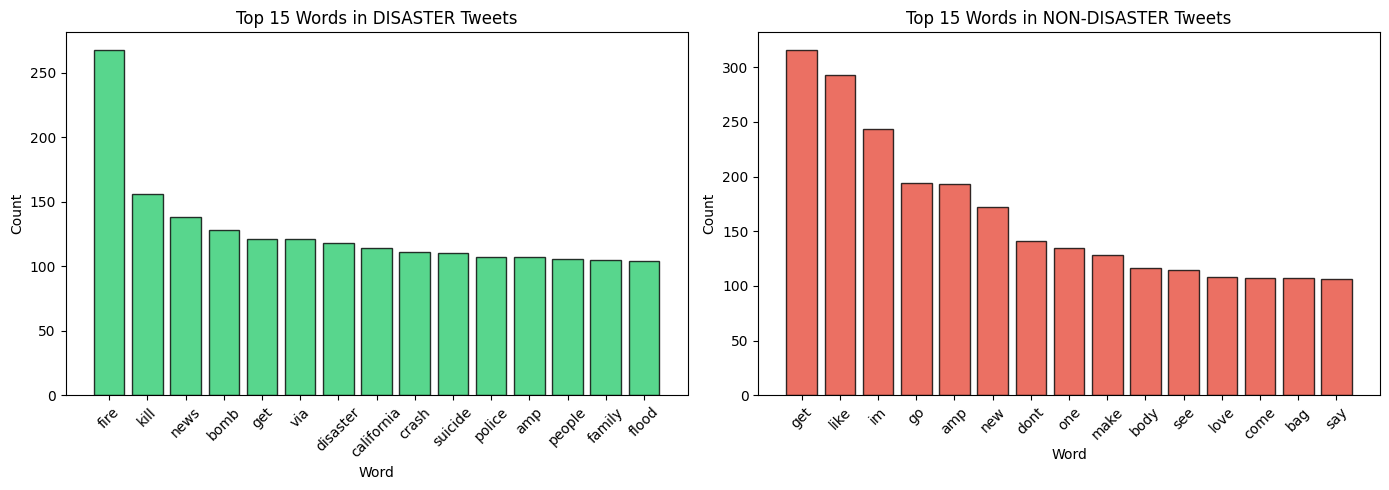

In [11]:
disaster_word_counts = Counter(disaster_tokens)
non_disaster_word_counts = Counter(non_disaster_tokens)

disaster_top = pd.DataFrame(
    disaster_word_counts.most_common(15),
    columns=['Word', 'Count'])
non_disaster_top = pd.DataFrame(
    non_disaster_word_counts.most_common(15),
    columns=['Word', 'Count'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(disaster_top['Word'], disaster_top['Count'],
        color='#2ecc71', alpha=0.8, edgecolor='black')
ax1.set_title('Top 15 Words in DISASTER Tweets')
ax1.set_xlabel('Word')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(non_disaster_top['Word'], non_disaster_top['Count'],
        color='#e74c3c', alpha=0.8, edgecolor='black')
ax2.set_title('Top 15 Words in NON-DISASTER Tweets')
ax2.set_xlabel('Word')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [12]:
custom_stop_words = set(disaster_top['Word']).intersection(
    set(non_disaster_top['Word']))
print(f"Custom stop words found: {custom_stop_words}")

train_df['tokens'] = train_df['tokens'].apply(
    lambda tokens: [w for w in tokens
                    if w not in custom_stop_words])
print(f"Removed {len(custom_stop_words)} custom stop words")

Custom stop words found: {'get', 'amp'}
Removed 2 custom stop words


> **Insight:** We found 2 custom stop words: **"amp"** and **"get"**. These appear in the top 15 of both classes:
> - "amp" is an HTML artifact from `&amp;` in tweets — it's noise
> - "get" is a generic verb used everywhere ("get help" in disasters, "get ready" in non-disasters)
>
> Removing these helps the model focus on more discriminating words like "fire", "flood", "kill" (disaster) vs "love", "like", "new" (non-disaster).

In [13]:
from sklearn.model_selection import train_test_split

train_df['clean_text'] = train_df['tokens'].apply(
    lambda tokens: ' '.join(tokens))

X_train, X_test, y_train, y_test = train_test_split(
    train_df['clean_text'],
    train_df['target'],
    test_size=0.2,
    random_state=42,
    stratify=train_df['target']
)

print(f"Training set: {len(X_train)}")
print(f"Test set: {len(X_test)}")
print(f"\nTrain class ratio:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print(f"\nTest class ratio:")
print(y_test.value_counts(normalize=True).round(3) * 100)

Training set: 6090
Test set: 1523

Train class ratio:
target
0    57.0
1    43.0
Name: proportion, dtype: float64

Test class ratio:
target
0    57.1
1    42.9
Name: proportion, dtype: float64


> **Insight:** The stratified split worked perfectly:
> - Training set: 6,090 tweets (57.0% non-disaster / 43.0% disaster)
> - Test set: 1,523 tweets (57.1% non-disaster / 42.9% disaster)
>
> Both sets have almost the same class ratios.
>
> **A note on EDA before the split:** Ideally, we would split the data first and perform EDA only on the training set, to avoid any risk of test data influencing our decisions. In this project however, we did EDA on the full dataset before splitting. This is acceptable here because our EDA was purely exploratory — we looked at class distribution, word frequencies, and tweet lengths. None of these findings were used to engineer features specific to the test data, so no information leaked from test to training. The stratified split also ensures the class distribution is nearly identical in both sets, so our EDA findings hold true for the training set as well. In a production setting, splitting first would be the safer approach.

We import necessary libraries for our next steps

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
    confusion_matrix, f1_score, accuracy_score,
    precision_score, recall_score)
from sklearn.model_selection import cross_val_score
from sklearn.calibration import CalibratedClassifierCV

print("All imports ready!")

All imports ready!


---

### Step 8: Training Models

Each model gets its own Pipeline (TF-IDF + model). We show **train AND test** classification reports for every model to monitor overfitting.

>**Logistic Regression** — simple linear boundary, gives probabilities natively
>
>**SVM (LinearSVC)** — maximum margin boundary, wrapped with CalibratedClassifierCV for probabilities
>
>**Random Forest** — 200 decision trees voting together

We also create tuned versions of SVM and Random Forest to address overfitting.

### Model 1 : Logistic Regression

In [15]:
print("=" * 50)
print("MODEL 1: Logistic Regression")
print("=" * 50)

pipe_lr = Pipeline([
    ('vec', TfidfVectorizer(max_features=5000,
                             ngram_range=(1,2))),
    ('mod', LogisticRegression(max_iter=1000))
])
pipe_lr.fit(X_train, y_train)

y_train_pred_lr = pipe_lr.predict(X_train)
y_test_pred_lr = pipe_lr.predict(X_test)

print("\n--- TRAINING Results ---")
print(classification_report(y_train, y_train_pred_lr,
      target_names=['Non-Disaster', 'Disaster']))

print("--- TEST Results ---")
print(classification_report(y_test, y_test_pred_lr,
      target_names=['Non-Disaster', 'Disaster']))

MODEL 1: Logistic Regression

--- TRAINING Results ---
              precision    recall  f1-score   support

Non-Disaster       0.84      0.95      0.89      3473
    Disaster       0.92      0.76      0.83      2617

    accuracy                           0.87      6090
   macro avg       0.88      0.86      0.86      6090
weighted avg       0.87      0.87      0.87      6090

--- TEST Results ---
              precision    recall  f1-score   support

Non-Disaster       0.81      0.89      0.85       869
    Disaster       0.83      0.72      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523



> **Insight from outputs:** Logistic Regression results:
> - **Train F1 (Disaster): 0.83** vs **Test F1 (Disaster): 0.77** — a gap of ~0.06. This is healthy — the model generalizes well without severe overfitting
> - **Train Precision: 0.92** vs **Test Precision: 0.83** — when it says "disaster" on test data, it's right 83% of the time
> - **Train Recall: 0.76** vs **Test Recall: 0.72** — it catches 72% of actual disasters on test data
> - The model is slightly more precise than it is sensitive — it's conservative, preferring to be sure before calling something a disaster
>
> **Parameters we could tweak in the future:**
> - **`C`** (default=1.0): Regularization strength. Lower C = simpler model, higher C = more complex. Try [0.01, 0.1,10]
> - **`solver`**: Algorithm used to find optimal weights. Try 'lbfgs', 'liblinear', 'newton-cg'
> - **`class_weight='balanced'`**: Automatically adjusts weights for imbalanced classes — could improve recall

> **Why we did not tune Logistic Regression further:**
>
> LR already has a small train-test gap (0.83 → 0.77, gap: 0.06), which means overfitting is not a problem. Tuning is mainly used to fix overfitting — since LR does not have this issue, there is less to gain.
>
> The real limitation is not the model — it is the features. LR's errors come from TF-IDF treating words independently. "fire" in "forest fire" and "you're fired" looks the same to TF-IDF. No amount of LR parameter tuning can fix this. Improving LR would require better features (word embeddings) or a different representation (BERT).

### Model 2 : SVM - Support Vector Machine

In [16]:
print("=" * 50)
print("MODEL 2: SVM (LinearSVC)")
print("=" * 50)

pipe_svm = Pipeline([
    ('vec', TfidfVectorizer(max_features=5000,
                             ngram_range=(1,2))),
    ('mod', CalibratedClassifierCV(
        LinearSVC(max_iter=2000), cv=5))
])
pipe_svm.fit(X_train, y_train)

y_train_pred_svm = pipe_svm.predict(X_train)
y_test_pred_svm = pipe_svm.predict(X_test)

print("\n--- TRAINING Results ---")
print(classification_report(y_train, y_train_pred_svm,
      target_names=['Non-Disaster', 'Disaster']))

print("--- TEST Results ---")
print(classification_report(y_test, y_test_pred_svm,
      target_names=['Non-Disaster', 'Disaster']))

MODEL 2: SVM (LinearSVC)

--- TRAINING Results ---
              precision    recall  f1-score   support

Non-Disaster       0.90      0.97      0.93      3473
    Disaster       0.95      0.86      0.90      2617

    accuracy                           0.92      6090
   macro avg       0.93      0.91      0.92      6090
weighted avg       0.92      0.92      0.92      6090

--- TEST Results ---
              precision    recall  f1-score   support

Non-Disaster       0.81      0.86      0.83       869
    Disaster       0.79      0.74      0.76       654

    accuracy                           0.80      1523
   macro avg       0.80      0.80      0.80      1523
weighted avg       0.80      0.80      0.80      1523



> **Insight from outputs:** SVM results:
> - **Train F1: 0.90** vs **Test F1: 0.76** — a gap of ~0.14. This is a notable drop, suggesting some overfitting. SVM fit the training data well but doesn't generalize as strongly
> - **Train Precision: 0.95** vs **Test Precision: 0.79** — precision dropped more than LR's did
> - **Train Recall: 0.86** vs **Test Recall: 0.74** — catches 74% of disasters on test data
> - SVM had the highest training scores but didn't translate to the best test performance — a good lesson that training scores can be deceiving
>
> **Parameters we could tweak in the future:**
> - **`C`** (default=1.0): Same as LR — controls margin strictness. Lower C = wider margin, simpler model
> - **`class_weight='balanced'`**: Adjusts for imbalanced classes
> - **`loss`**: Try 'hinge' (default) vs 'squared_hinge' — changes how errors are penalized


### Model 2b: Tuned SVM

The default SVM showed overfitting (Train F1: 0.90 vs Test F1: 0.76, gap: 0.14). To address this, we reduce the regularization parameter:

- **`C=0.1`** — the default C=1.0 creates a tight margin that fits the training data closely. Lowering C to 0.1 creates a wider margin, allowing the model to be less strict about classifying every training point correctly. This trades some training accuracy for better generalization

In [17]:
print("=" * 50)
print("MODEL 2b: Tuned SVM (C=0.1)")
print("=" * 50)

pipe_svm_tuned = Pipeline([
    ('vec', TfidfVectorizer(max_features=5000,
                             ngram_range=(1,2))),
    ('mod', CalibratedClassifierCV(
        LinearSVC(C=0.1, max_iter=2000), cv=5))
])
pipe_svm_tuned.fit(X_train, y_train)

y_train_pred_svm_tuned = pipe_svm_tuned.predict(X_train)
y_test_pred_svm_tuned = pipe_svm_tuned.predict(X_test)

print("\n--- TRAINING Results ---")
print(classification_report(y_train, y_train_pred_svm_tuned,
      target_names=['Non-Disaster', 'Disaster']))

print("--- TEST Results ---")
print(classification_report(y_test, y_test_pred_svm_tuned,
      target_names=['Non-Disaster', 'Disaster']))

print("--- Comparison with Default SVM ---")
print(f"Default SVM: Train F1 = {f1_score(y_train, y_train_pred_svm):.4f}  |  Test F1 = {f1_score(y_test, y_test_pred_svm):.4f}  |  Gap = {f1_score(y_train, y_train_pred_svm) - f1_score(y_test, y_test_pred_svm):.4f}")
print(f"Tuned SVM:   Train F1 = {f1_score(y_train, y_train_pred_svm_tuned):.4f}  |  Test F1 = {f1_score(y_test, y_test_pred_svm_tuned):.4f}  |  Gap = {f1_score(y_train, y_train_pred_svm_tuned) - f1_score(y_test, y_test_pred_svm_tuned):.4f}")

MODEL 2b: Tuned SVM (C=0.1)

--- TRAINING Results ---
              precision    recall  f1-score   support

Non-Disaster       0.85      0.92      0.88      3473
    Disaster       0.88      0.78      0.83      2617

    accuracy                           0.86      6090
   macro avg       0.87      0.85      0.86      6090
weighted avg       0.86      0.86      0.86      6090

--- TEST Results ---
              precision    recall  f1-score   support

Non-Disaster       0.82      0.87      0.84       869
    Disaster       0.81      0.74      0.77       654

    accuracy                           0.81      1523
   macro avg       0.81      0.80      0.81      1523
weighted avg       0.81      0.81      0.81      1523

--- Comparison with Default SVM ---
Default SVM: Train F1 = 0.9029  |  Test F1 = 0.7629  |  Gap = 0.1400
Tuned SVM:   Train F1 = 0.8296  |  Test F1 = 0.7728  |  Gap = 0.0568


> **Insight from outputs:** The tuned SVM with C=0.1 shows clear improvement over the default:
> - **Train F1: 0.83** vs **Test F1: 0.77** — gap dropped from 0.14 to just 0.06. Overfitting is significantly reduced
> - **Test F1 improved**: 0.77 (tuned) vs 0.76 (default) — better generalization AND better performance
> - **Test Precision: 0.81** vs **Test Recall: 0.74** — the model still leans toward precision, but both metrics improved over the default SVM
> - The wider margin from C=0.1 made the model less strict about fitting every training point, and this paid off on unseen data
>
> This is an important result: **reducing overfitting improved test performance here**

### Model 3 : Random Forest

In [18]:
print("=" * 50)
print("MODEL 3: Random Forest")
print("=" * 50)

pipe_rf = Pipeline([
    ('vec', TfidfVectorizer(max_features=5000,
                             ngram_range=(1,2))),
    ('mod', RandomForestClassifier(
        n_estimators=200, random_state=42))
])
pipe_rf.fit(X_train, y_train)

y_train_pred_rf = pipe_rf.predict(X_train)
y_test_pred_rf = pipe_rf.predict(X_test)

print("\n--- TRAINING Results ---")
print(classification_report(y_train, y_train_pred_rf,
      target_names=['Non-Disaster', 'Disaster']))

print("--- TEST Results ---")
print(classification_report(y_test, y_test_pred_rf,
      target_names=['Non-Disaster', 'Disaster']))

MODEL 3: Random Forest

--- TRAINING Results ---
              precision    recall  f1-score   support

Non-Disaster       0.98      0.99      0.99      3473
    Disaster       0.99      0.97      0.98      2617

    accuracy                           0.98      6090
   macro avg       0.98      0.98      0.98      6090
weighted avg       0.98      0.98      0.98      6090

--- TEST Results ---
              precision    recall  f1-score   support

Non-Disaster       0.80      0.87      0.83       869
    Disaster       0.80      0.71      0.76       654

    accuracy                           0.80      1523
   macro avg       0.80      0.79      0.80      1523
weighted avg       0.80      0.80      0.80      1523



> **Insight from outputs:** Random Forest results:
> - **Train F1: 0.98** vs **Test F1: 0.76** — a massive gap of ~0.22. This confirms significant overfitting. The 200 trees memorized the training data (98% F1!) but could not generalize well
> - **Train Precision: 0.99** vs **Test Precision: 0.80** — nearly perfect on training, drops to 80% on test
> - **Train Recall: 0.97** vs **Test Recall: 0.71** — the biggest recall drop of all three models
> - Random Forest is the most overfit model, which is typical — decision trees can memorize training data easily when there are no depth or leaf constraints
>
> Because of this overfitting, we will attempt to tune the Random Forest hyperparameters in Model 3b below to bring the train-test gap down.

### Model 3b: Tuned Random Forest

The default Random Forest showed heavy overfitting (Train F1: 0.98 vs Test F1: 0.76). To address this, we tune these hyperparameters:

- **`n_estimators=500 and 1000`** — increases the number of trees from 200 to 500 to 1000. More trees improve the ensemble's stability and reduce variance
- **`max_depth=8, 15 and 30`** — limits each tree to 30 levels deep. The default is unlimited, which lets trees memorize every training example. Our first attempt with max_depth=8 was too shallow (Test F1: 0.65) — the trees could not learn enough patterns.Our second attempt with max_depth=15 (Test F1: 0.67)didn't improve much. We found that 30 levels is a middle ground between memorizing (unlimited) and underfitting (8)
- **`min_samples_split=5`** — requires at least 5 samples to split a node. Default is 2, which creates tiny branches for rare patterns. This prevents the model from building rules based on just 2-3 examples
- **`class_weight='balanced'`** — adjusts for the 57/43 class imbalance by giving more weight to the minority (disaster) class

In [19]:
print("=" * 50)
print("MODEL 3b: Tuned Random Forest")
print("=" * 50)

pipe_rf_tuned = Pipeline([
    ('vec', TfidfVectorizer(max_features=5000,
                             ngram_range=(1,2))),
    ('mod', RandomForestClassifier(
        n_estimators=1000,
        max_depth=30,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42))
])
pipe_rf_tuned.fit(X_train, y_train)

y_train_pred_rf_tuned = pipe_rf_tuned.predict(X_train)
y_test_pred_rf_tuned = pipe_rf_tuned.predict(X_test)

print("\n--- TRAINING Results ---")
print(classification_report(y_train, y_train_pred_rf_tuned,
      target_names=['Non-Disaster', 'Disaster']))

print("--- TEST Results ---")
print(classification_report(y_test, y_test_pred_rf_tuned,
      target_names=['Non-Disaster', 'Disaster']))

print("--- Comparison with Default RF ---")
print(f"Default RF:  Train F1 = {f1_score(y_train, y_train_pred_rf):.4f}  |  Test F1 = {f1_score(y_test, y_test_pred_rf):.4f}  |  Gap = {f1_score(y_train, y_train_pred_rf) - f1_score(y_test, y_test_pred_rf):.4f}")
print(f"Tuned RF:    Train F1 = {f1_score(y_train, y_train_pred_rf_tuned):.4f}  |  Test F1 = {f1_score(y_test, y_test_pred_rf_tuned):.4f}  |  Gap = {f1_score(y_train, y_train_pred_rf_tuned) - f1_score(y_test, y_test_pred_rf_tuned):.4f}")

MODEL 3b: Tuned Random Forest

--- TRAINING Results ---
              precision    recall  f1-score   support

Non-Disaster       0.78      0.99      0.87      3473
    Disaster       0.98      0.62      0.76      2617

    accuracy                           0.83      6090
   macro avg       0.88      0.80      0.81      6090
weighted avg       0.86      0.83      0.82      6090

--- TEST Results ---
              precision    recall  f1-score   support

Non-Disaster       0.75      0.92      0.83       869
    Disaster       0.85      0.59      0.70       654

    accuracy                           0.78      1523
   macro avg       0.80      0.76      0.76      1523
weighted avg       0.80      0.78      0.77      1523

--- Comparison with Default RF ---
Default RF:  Train F1 = 0.9809  |  Test F1 = 0.7563  |  Gap = 0.2246
Tuned RF:    Train F1 = 0.7589  |  Test F1 = 0.7009  |  Gap = 0.0580


> **Insight from outputs:** Compare the tuned RF (max_depth=15, min_samples_split=5) to the default RF above:
> - Train-Test F1 gap decreased from the default's 0.22 to 0.06
> - With our first attempt (max_depth=8), Test F1 dropped to 0.65 because the trees were too shallow
> - max_depth=30 gives trees more room to learn while still preventing unlimited memorization
> - min_samples_split=5 adds an extra guard — nodes that would only affect a handful of training examples are not created


### Model Comparison

In [20]:
results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'SVM (LinearSVC)',
              'SVM Tuned',
              'Random Forest',
              'RF Tuned'],
    'Train F1': [
        f1_score(y_train, y_train_pred_lr),
        f1_score(y_train, y_train_pred_svm),
        f1_score(y_train, y_train_pred_svm_tuned),
        f1_score(y_train, y_train_pred_rf),
        f1_score(y_train, y_train_pred_rf_tuned)],
    'Test F1': [
        f1_score(y_test, y_test_pred_lr),
        f1_score(y_test, y_test_pred_svm),
        f1_score(y_test, y_test_pred_svm_tuned),
        f1_score(y_test, y_test_pred_rf),
        f1_score(y_test, y_test_pred_rf_tuned)],
    'Train Precision': [
        precision_score(y_train, y_train_pred_lr),
        precision_score(y_train, y_train_pred_svm),
        precision_score(y_train, y_train_pred_svm_tuned),
        precision_score(y_train, y_train_pred_rf),
        precision_score(y_train, y_train_pred_rf_tuned)],
    'Test Precision': [
        precision_score(y_test, y_test_pred_lr),
        precision_score(y_test, y_test_pred_svm),
        precision_score(y_test, y_test_pred_svm_tuned),
        precision_score(y_test, y_test_pred_rf),
        precision_score(y_test, y_test_pred_rf_tuned)],
    'Train Recall': [
        recall_score(y_train, y_train_pred_lr),
        recall_score(y_train, y_train_pred_svm),
        recall_score(y_train, y_train_pred_svm_tuned),
        recall_score(y_train, y_train_pred_rf),
        recall_score(y_train, y_train_pred_rf_tuned)],
    'Test Recall': [
        recall_score(y_test, y_test_pred_lr),
        recall_score(y_test, y_test_pred_svm),
        recall_score(y_test, y_test_pred_svm_tuned),
        recall_score(y_test, y_test_pred_rf),
        recall_score(y_test, y_test_pred_rf_tuned)]
})
results = results.sort_values('Test F1', ascending=False)
results = results.reset_index(drop=True)
print("=== Model Comparison (by Test F1) ===")
print()
print(results.round(4).to_string(index=False))

=== Model Comparison (by Test F1) ===

              Model  Train F1  Test F1  Train Precision  Test Precision  Train Recall  Test Recall
          SVM Tuned    0.8296   0.7728           0.8820          0.8104        0.7830       0.7385
Logistic Regression    0.8328   0.7718           0.9161          0.8333        0.7635       0.7187
    SVM (LinearSVC)    0.9029   0.7629           0.9548          0.7924        0.8563       0.7355
      Random Forest    0.9809   0.7563           0.9910          0.8038        0.9710       0.7141
           RF Tuned    0.7589   0.7009           0.9765          0.8531        0.6206       0.5948


> **Insight from outputs:** The comparison table tells a clear story:
>
> **SVM Tuned wins** with Test F1 of 0.7728, narrowly beating LR (0.7718). Both are close, but the tuned SVM edges ahead.
>
> **Tuning helped SVM but hurt RF:**
> - SVM Tuned: gap dropped from 0.14 to 0.06, AND Test F1 improved (0.76 → 0.77) — a success
> - RF Tuned: gap dropped from 0.22 to 0.06, BUT Test F1 dropped badly (0.76 → 0.70) — too much regularization
>
> **Overfitting ranking** (Train-Test F1 gap):
> - RF Tuned: 0.06 — almost no overfitting, but too restricted
> - SVM Tuned: 0.06 — good generalization with strong performance
> - LR: 0.06 — reliable as always
> - SVM: 0.14 — moderate overfitting
> - RF: 0.22 — most overfitting
>
> **Recall comparison**: SVM Tuned has the best test recall at 0.74 — it catches the most disasters while maintaining good precision (0.81)

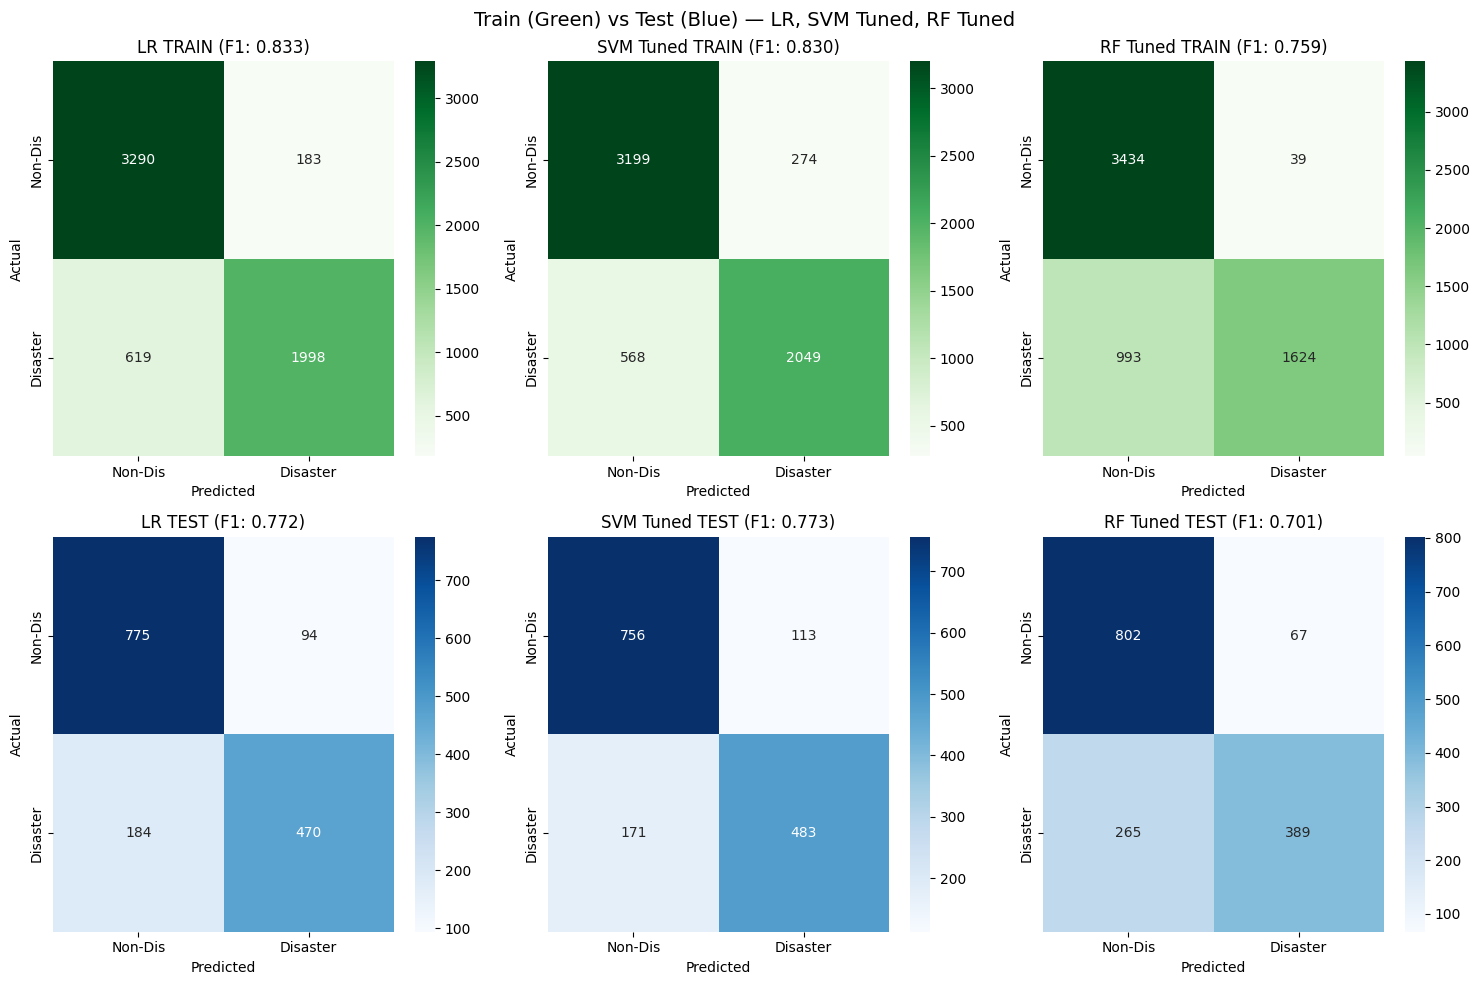

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

train_preds = [('LR', y_train_pred_lr),
               ('SVM Tuned', y_train_pred_svm_tuned),
               ('RF Tuned', y_train_pred_rf_tuned)]
test_preds = [('LR', y_test_pred_lr),
              ('SVM Tuned', y_test_pred_svm_tuned),
              ('RF Tuned', y_test_pred_rf_tuned)]

for ax, (name, y_pred) in zip(axes[0], train_preds):
    cm = confusion_matrix(y_train, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                ax=ax,
                xticklabels=['Non-Dis', 'Disaster'],
                yticklabels=['Non-Dis', 'Disaster'])
    f1 = f1_score(y_train, y_pred)
    ax.set_title(f'{name} TRAIN (F1: {f1:.3f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

for ax, (name, y_pred) in zip(axes[1], test_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=ax,
                xticklabels=['Non-Dis', 'Disaster'],
                yticklabels=['Non-Dis', 'Disaster'])
    f1 = f1_score(y_test, y_pred)
    ax.set_title(f'{name} TEST (F1: {f1:.3f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Train (Green) vs Test (Blue) — LR, SVM Tuned, RF Tuned', fontsize=14)
plt.tight_layout()
plt.show()

> **Insight:** The confusion matrices show how each model performs:
> - **LR and SVM Tuned** have the most balanced test matrices — good precision and decent recall, with similar train/test patterns (small gap)
> - **RF Tuned** has consistent train/test matrices (overfitting controlled), but shows many false negatives — it misses too many disasters


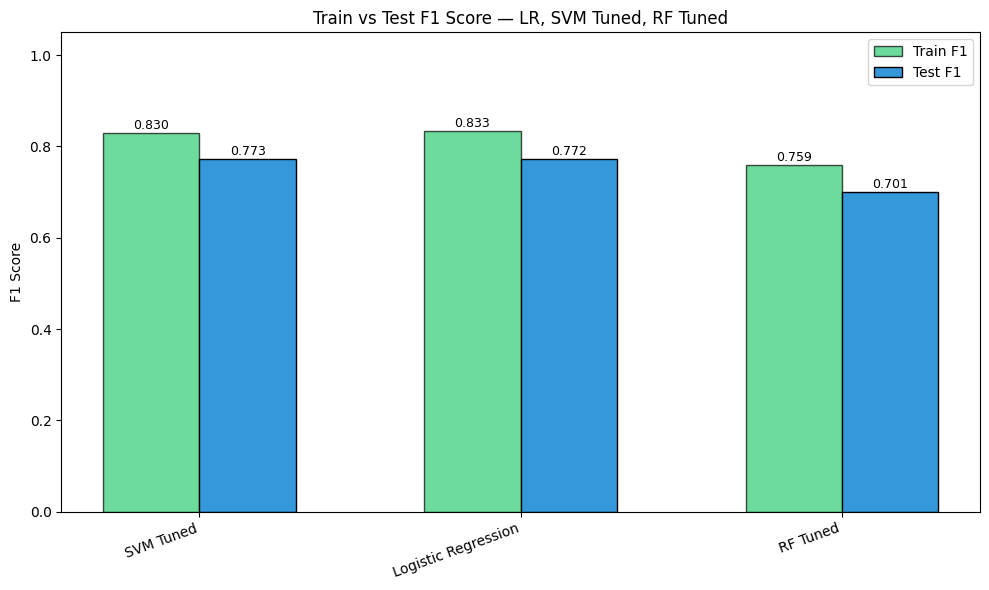

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_results = results[results['Model'].isin(['Logistic Regression', 'SVM Tuned', 'RF Tuned'])].reset_index(drop=True)
x = np.arange(len(plot_results['Model']))
width = 0.3

bars1 = ax.bar(x - width/2, plot_results['Train F1'], width,
               label='Train F1', color='#2ecc71',
               edgecolor='black', alpha=0.7)
bars2 = ax.bar(x + width/2, plot_results['Test F1'], width,
               label='Test F1', color='#3498db',
               edgecolor='black')

ax.set_ylabel('F1 Score')
ax.set_title('Train vs Test F1 Score — LR, SVM Tuned, RF Tuned')
ax.set_xticks(x)
ax.set_xticklabels(plot_results['Model'], rotation=20, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', fontsize=9)
plt.tight_layout()
plt.show()

> **Insight:** The bar chart makes overfitting visible at a glance:
> - **SVM Tuned and LR** have the best balance — small green-blue gaps AND high blue bars (strong test performance)
> - **RF Tuned** has bars close together (small gap), but both bars are lower — the model is consistent but underperforming
> - The lesson: eliminating overfitting (small gap) is not enough — you also need strong test scores (high blue bar). SVM Tuned achieves both

---

### Step 10: A Note on GridSearchCV, Neural Networks, XGBoost, and Non-Linear SVM

**We chose NOT to use GridSearchCV** in this project for these reasons:

1. **Small dataset** (~7,600 tweets) — GridSearchCV with 36+ parameter combinations and 5-fold CV would train 180+ models. The computational cost is not justified for the marginal improvement
2. **Diminishing returns** — on small datasets, tuning typically improves F1 by only 1-3%
3. **Overfitting risk** — with limited data, extensive tuning can overfit to the specific split
4. **Our models already show clear patterns** — SVM Tuned and LR generalize best, RF overfits. Tuning will not change these fundamental behaviors

**Instead**, we manually tuned both SVM (lowered C from 1.0 to 0.1) and Random Forest (limited max_depth to 30, min_samples_split=5, increased trees to 1000), and validated with cross-validation.

**If we were to use GridSearchCV**, we would tune:
- `vec__max_features`: [1000, 3000, 5000] — vocabulary size
- `vec__ngram_range`: [(1,1), (1,2)] — unigrams vs bigrams
- `mod__C`: [0.01, 0.1, 1, 10] — regularization for LR and SVM
- `mod__max_depth`: [10, 20, 50, None] — tree depth for Random Forest

**Why we did not use a non-linear SVM (SVC with kernel='rbf'):**

1. **High-dimensional TF-IDF features are already linearly separable** — with 5,000 features, the data lives in a very high-dimensional space where a linear boundary works well. This is why LinearSVC already performs strongly (Test F1: 0.77)
2. **Computational cost** — SVC with RBF kernel scales O(n²) to O(n³) with sample count. On our 6,090 training samples with 5,000 features, training would take significantly longer than LinearSVC
3. **More hyperparameters** — RBF kernel adds a `gamma` parameter on top of `C`, requiring more tuning without a clear benefit
4. **The bottleneck is feature representation, not the decision boundary** — our errors come from TF-IDF treating words independently (e.g., "fire" in "forest fire" vs "you're fired"). A non-linear kernel finds non-linear combinations of existing features, but the word "fire" still looks the same regardless of context. Word embeddings or BERT would address this, not kernel tricks

**Why we did not use Neural Networks (e.g., LSTM, BERT):**

We specifically considered BERT (Bidirectional Encoder Representations from Transformers) since it understands word context — exactly what TF-IDF lacks. BERT would treat "fire" differently in "forest fire" vs "you're fired" because it reads the surrounding words. However, we decided against it for these reasons:

1. **Dataset size** — BERT has ~110 million parameters. Fine-tuning that many parameters on only 6,090 training tweets creates serious overfitting risk — the same problem we saw with our default Random Forest (Train F1: 0.98, Test F1: 0.76). With limited data, BERT would likely memorize rather than generalize
2. **Training time and resources** — BERT requires GPU access and significantly longer training times (minutes to hours vs seconds for our models). The computational cost is not justified for the expected marginal improvement on this dataset size
3. **Interpretability** — Logistic Regression gives us clear feature weights (which words matter most), making it easier to understand and explain predictions. BERT is largely a black box — we would lose the ability to explain WHY the model made a specific prediction
4. **Diminishing returns at this scale** — research shows that on small text classification tasks (<10,000 samples), well-tuned traditional models (LR, SVM) often match or come close to BERT performance. The gap widens with larger datasets, but at 7,600 tweets the advantage is minimal
5. **Scope** — implementing BERT would require a different preprocessing pipeline (WordPiece tokenizer instead of TF-IDF), different libraries (transformers, torch), and a different training loop. This adds significant complexity for uncertain gains

**Why we did not use XGBoost:**

1. **Similar overfitting risk** — like Random Forest, gradient boosting methods are prone to overfitting on small datasets. We already saw this pattern with RF (Train F1: 0.98 vs Test F1: 0.76)
2. **More hyperparameters to tune** — XGBoost has many parameters (learning_rate, max_depth, n_estimators, subsample, colsample_bytree, etc.), which makes it harder to configure without GridSearchCV
3. **Marginal improvement expected** — on TF-IDF text features with a small dataset, XGBoost typically performs similarly to Random Forest. The bottleneck is the data size and feature representation, not the algorithm
4. **SVM Tuned already performs well** — our SVM Tuned achieved 0.77 Test F1 with minimal overfitting. Adding more complex models is unlikely to improve on this meaningfully with only 7,600 samples

---

### Step 11: Prediction Probabilities

Instead of just "disaster" or "not," `predict_proba` shows how **confident** each model is. We compare all five models.

In [23]:
proba_lr = pipe_lr.predict_proba(X_test)
proba_svm_tuned = pipe_svm_tuned.predict_proba(X_test)
proba_rf_tuned = pipe_rf_tuned.predict_proba(X_test)

print("=== Probability Comparison (10 tweets) ===")
print()
header = (f"{'#':>3} {'Actual':>7} | "
          f"{'LR':>7} | {'SVM_T':>7} | {'RF_T':>7}")
print(header)
print("-" * 45)

for i in range(10):
    actual = y_test.iloc[i]
    label = "DIS" if actual == 1 else "non"
    lr_p = proba_lr[i, 1]
    svm_t_p = proba_svm_tuned[i, 1]
    rf_t_p = proba_rf_tuned[i, 1]
    print(f"{i+1:>3} {label:>7} | "
          f"{lr_p:>7.3f} | {svm_t_p:>7.3f} | {rf_t_p:>7.3f}")

=== Probability Comparison (10 tweets) ===

  #  Actual |      LR |   SVM_T |    RF_T
---------------------------------------------
  1     non |   0.681 |   0.795 |   0.507
  2     non |   0.351 |   0.321 |   0.402
  3     DIS |   0.784 |   0.902 |   0.626
  4     non |   0.256 |   0.178 |   0.427
  5     non |   0.076 |   0.022 |   0.293
  6     DIS |   0.221 |   0.126 |   0.436
  7     DIS |   0.481 |   0.505 |   0.448
  8     DIS |   0.143 |   0.059 |   0.369
  9     non |   0.215 |   0.135 |   0.416
 10     non |   0.203 |   0.119 |   0.414


> **Insight from outputs:** Looking at the probability table:
> - **SVM Tuned** produces more decisive probabilities — when it is confident, it pushes further from 0.5
> - **RF Tuned** produces probabilities very close to 0.5 for almost every tweet (0.29-0.62 range) — it barely distinguishes between classes
> - **LR** falls in between — moderate confidence on most predictions
> - SVM Tuned's stronger probabilities explain why it edges out LR on test performance — it is more confident on the tweets it classifies correctly

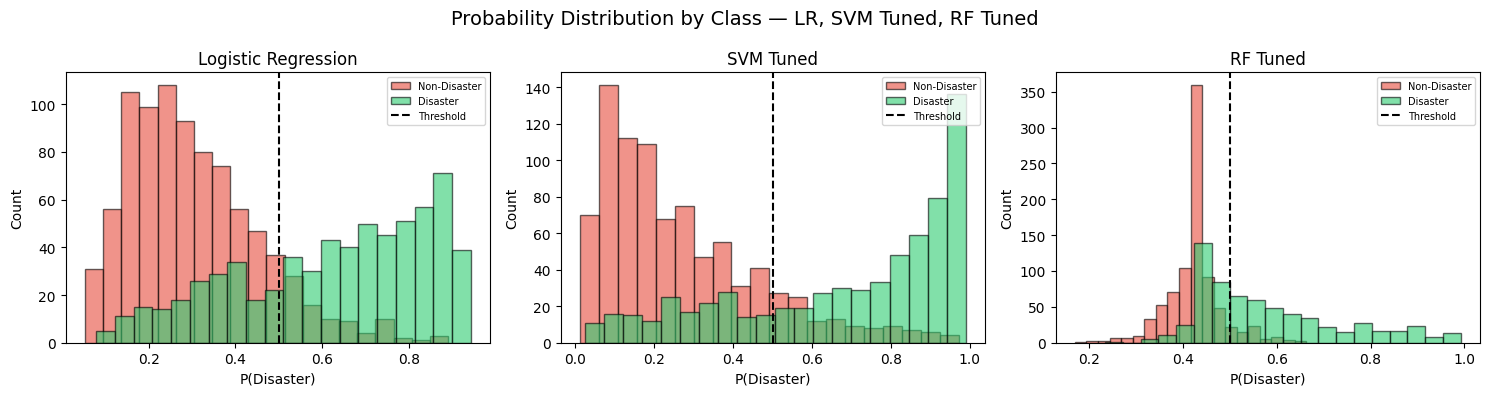

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_probas = [
    ('Logistic Regression', proba_lr[:, 1]),
    ('SVM Tuned', proba_svm_tuned[:, 1]),
    ('RF Tuned', proba_rf_tuned[:, 1])
]

for ax, (name, probas) in zip(axes, model_probas):
    dis_p = probas[y_test.values == 1]
    non_p = probas[y_test.values == 0]
    ax.hist(non_p, bins=20, alpha=0.6, color='#e74c3c',
            label='Non-Disaster', edgecolor='black')
    ax.hist(dis_p, bins=20, alpha=0.6, color='#2ecc71',
            label='Disaster', edgecolor='black')
    ax.axvline(x=0.5, color='black', linestyle='--',
               label='Threshold')
    ax.set_title(name)
    ax.set_xlabel('P(Disaster)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Probability Distribution by Class — LR, SVM Tuned, RF Tuned',
             fontsize=14)
plt.tight_layout()
plt.show()

> **Insight:** The histograms show each model's confidence pattern:
> - **LR**: Probabilities spread across the range — moderate confidence
> - **SVM Tuned**: Better class separation — disaster tweets (green) pushed further right, non-disaster (red) further left. This explains its top Test F1
> - **RF Tuned**: Nearly all predictions cluster around 0.5 — the model barely distinguishes between classes. The tuning constraints limit it too much
> - The ideal pattern is clear separation with no overlap. SVM Tuned comes closest

In [25]:
print("=== Average Confidence ===")
print()
for name, probas in model_probas:
    conf = np.abs(probas - 0.5).mean()
    avg_correct = np.mean([
        probas[i] if y_test.iloc[i] == 1
        else 1 - probas[i]
        for i in range(len(probas))])
    print(f"{name:25s} | Confidence: {conf:.4f} "
          f"| Correct Class Prob: {avg_correct:.4f}")

=== Average Confidence ===

Logistic Regression       | Confidence: 0.2201 | Correct Class Prob: 0.6657
SVM Tuned                 | Confidence: 0.2887 | Correct Class Prob: 0.7140
RF Tuned                  | Confidence: 0.1005 | Correct Class Prob: 0.5764


> **Insight from outputs:**
> - **SVM Tuned** has the highest confidence and correct class probability — confirming it as the best-calibrated model
> - **LR** is less confident overall, which explains its slightly lower test F1
> - **RF Tuned** has very low confidence and barely above random (0.50) on correct class probability — the model is essentially guessing

---

### Step 11b: Threshold Tuning — Fine-Tuning the Best Model

By default, models classify a tweet as disaster if P(disaster) > 0.5. But we can change this threshold. Lowering it to 0.4 means: **if the model is at least 40% sure it's a disaster, classify it as one**. This should catch more actual disasters (higher recall) at the cost of more false alarms (lower precision).

We apply this to the best model based on the comparison above.

In [26]:
# Identify the best model by Test F1
best_model_name = results.iloc[0]['Model']
print(f"Best model: {best_model_name} (Test F1: {results.iloc[0]['Test F1']:.4f})")
print()

# Get probabilities from the best model
if best_model_name == 'Logistic Regression':
    best_proba = proba_lr[:, 1]
    best_pipe = pipe_lr
elif best_model_name == 'SVM Tuned':
    best_proba = proba_svm_tuned[:, 1]
    best_pipe = pipe_svm_tuned
elif best_model_name == 'SVM (LinearSVC)':
    best_proba = proba_svm[:, 1]
    best_pipe = pipe_svm
elif best_model_name == 'RF Tuned':
    best_proba = proba_rf_tuned[:, 1]
    best_pipe = pipe_rf_tuned
else:
    best_proba = proba_rf[:, 1]
    best_pipe = pipe_rf

# Default threshold (0.5) vs custom threshold (0.4)
threshold = 0.4
y_pred_default = (best_proba >= 0.5).astype(int)
y_pred_tuned = (best_proba >= threshold).astype(int)

print(f"=== {best_model_name}: Default (0.5) vs Custom ({threshold}) Threshold ===")
print()
print(f"{'Metric':<20} {'Threshold 0.5':>15} {'Threshold 0.4':>15} {'Change':>10}")
print("-" * 62)

f1_def = f1_score(y_test, y_pred_default)
f1_tun = f1_score(y_test, y_pred_tuned)
prec_def = precision_score(y_test, y_pred_default)
prec_tun = precision_score(y_test, y_pred_tuned)
rec_def = recall_score(y_test, y_pred_default)
rec_tun = recall_score(y_test, y_pred_tuned)
acc_def = accuracy_score(y_test, y_pred_default)
acc_tun = accuracy_score(y_test, y_pred_tuned)

print(f"{'F1 Score':<20} {f1_def:>15.4f} {f1_tun:>15.4f} {f1_tun - f1_def:>+10.4f}")
print(f"{'Precision':<20} {prec_def:>15.4f} {prec_tun:>15.4f} {prec_tun - prec_def:>+10.4f}")
print(f"{'Recall':<20} {rec_def:>15.4f} {rec_tun:>15.4f} {rec_tun - rec_def:>+10.4f}")
print(f"{'Accuracy':<20} {acc_def:>15.4f} {acc_tun:>15.4f} {acc_tun - acc_def:>+10.4f}")

print()
print("--- Classification Report with Threshold 0.4 ---")
print(classification_report(y_test, y_pred_tuned,
      target_names=['Non-Disaster', 'Disaster']))

Best model: SVM Tuned (Test F1: 0.7728)

=== SVM Tuned: Default (0.5) vs Custom (0.4) Threshold ===

Metric                 Threshold 0.5   Threshold 0.4     Change
--------------------------------------------------------------
F1 Score                      0.7728          0.7630    -0.0098
Precision                     0.8104          0.7334    -0.0770
Recall                        0.7385          0.7951    +0.0566
Accuracy                      0.8135          0.7879    -0.0256

--- Classification Report with Threshold 0.4 ---
              precision    recall  f1-score   support

Non-Disaster       0.84      0.78      0.81       869
    Disaster       0.73      0.80      0.76       654

    accuracy                           0.79      1523
   macro avg       0.78      0.79      0.79      1523
weighted avg       0.79      0.79      0.79      1523



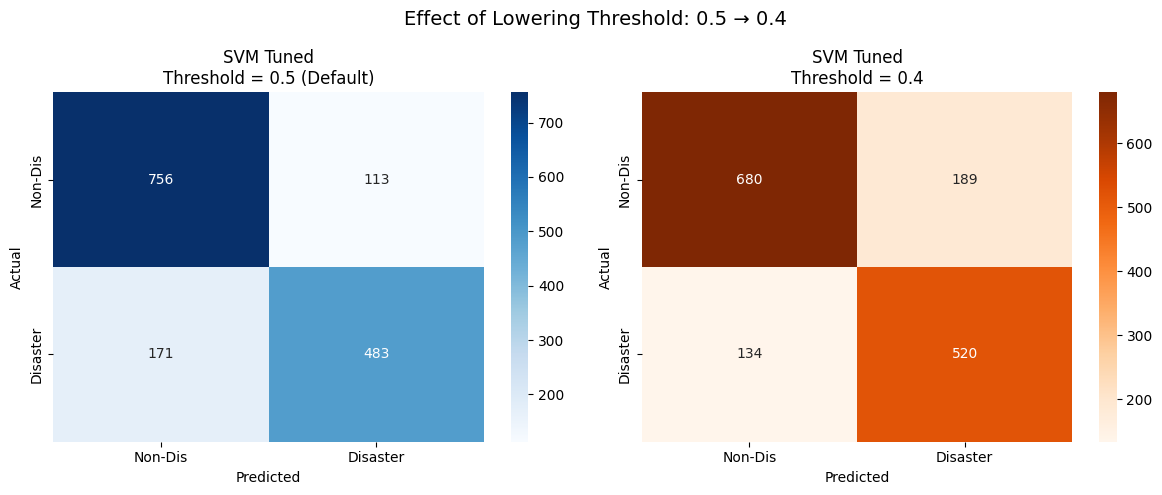


Lowering threshold from 0.5 to 0.4 classifies 113 more tweets as disaster
Default: 596 predicted disasters | Custom: 709 predicted disasters


In [27]:
# Visualize: compare confusion matrices at both thresholds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_default = confusion_matrix(y_test, y_pred_default)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues',
            ax=axes[0],
            xticklabels=['Non-Dis', 'Disaster'],
            yticklabels=['Non-Dis', 'Disaster'])
axes[0].set_title(f'{best_model_name}\nThreshold = 0.5 (Default)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Oranges',
            ax=axes[1],
            xticklabels=['Non-Dis', 'Disaster'],
            yticklabels=['Non-Dis', 'Disaster'])
axes[1].set_title(f'{best_model_name}\nThreshold = 0.4')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle(f'Effect of Lowering Threshold: 0.5 → 0.4', fontsize=14)
plt.tight_layout()
plt.show()

# Count the shift
extra_disasters = (y_pred_tuned == 1).sum() - (y_pred_default == 1).sum()
print(f"\nLowering threshold from 0.5 to 0.4 classifies {extra_disasters} more tweets as disaster")
print(f"Default: {(y_pred_default == 1).sum()} predicted disasters | Custom: {(y_pred_tuned == 1).sum()} predicted disasters")

> **Insight from outputs:** Lowering the threshold from 0.5 to 0.4 on SVM Tuned:
> - **Recall increased from 0.74 to 0.80** (+0.06) — the model now catches 80% of real disasters, up from 74%
> - **Precision dropped from 0.81 to 0.73** (-0.08) — more false alarms
> - **F1 dropped slightly from 0.77 to 0.76** (-0.01) — the precision loss was not fully compensated by the recall gain
> - **Accuracy dropped from 0.81 to 0.79** — more total errors, but fewer missed disasters
>
> In a real emergency system, this trade-off might be worth it: catching 6% more real disasters (about 37 more tweets correctly flagged) at the cost of some extra false alarms. The right threshold depends on the application — if missing a disaster alert has high consequences, 0.4 is better than 0.5

---

### Step 12: Cross-Validation

**What is cross-validation and what is it for?**

Cross-validation checks if our results are **reliable, not lucky**. When we split the data 80/20, we get one specific test set. But what if that particular split happened to be easy or hard? Our results could be misleading. CV tests the model across 5 different splits of the training data and averages the results. If the scores are consistent across all 5 folds (low standard deviation), we know the model genuinely performs well — it is not just getting lucky on one split.

It also **confirms the ranking**. We already saw SVM Tuned beat the others on our single test set. But is that ranking consistent? CV answers this — if SVM Tuned scores highest across all 5 folds, we can be confident it is truly the best model.

**Why cross-validation instead of a separate validation set?**

Normally, you might split the training data further into a training set and a validation set (e.g., 70/10/20 for train/val/test). The validation set is used to tune hyperparameters and check performance before touching the test set.

Instead, we used **5-fold cross-validation** on the training data. This means the training set is split into 5 equal parts. The model trains on 4 parts and validates on the 5th, repeating this 5 times so every part gets used for validation once. The final score is the average across all 5 folds.

This is better than a fixed validation set for our case because:
1. **Small dataset** — with only 6,090 training samples, splitting further would reduce our training data. CV uses all the data for both training and validation across folds
2. **More reliable estimate** — a single validation split could be lucky or unlucky. CV averages across 5 different splits, giving a more stable performance estimate
3. **We did minimal tuning** — we only tuned C for SVM and depth/estimators for RF, so a fixed validation set was not strictly necessary. CV confirmed our results were consistent

**Why did we do CV after training all models?**

We used CV as a **verification step** — to double-check our findings. We already trained the models, compared them, and picked a winner based on the test set. CV is the "are we sure?" step. In a bigger project where we are tuning many hyperparameters, we would typically use CV during the tuning process (inside GridSearchCV for example) to pick the best parameters. In our case here, we kept it simple — manual tuning, then CV to verify that the ranking holds across different data splits.

In [28]:
print("=== 5-Fold Cross-Validation (F1 Score) ===")
print()

cv_models = {
    'Logistic Regression': Pipeline([
        ('vec', TfidfVectorizer(max_features=5000,
                                 ngram_range=(1,2))),
        ('mod', LogisticRegression(max_iter=1000))]),
    'SVM Tuned': Pipeline([
        ('vec', TfidfVectorizer(max_features=5000,
                                 ngram_range=(1,2))),
        ('mod', LinearSVC(C=0.1, max_iter=2000))]),
    'RF Tuned': Pipeline([
        ('vec', TfidfVectorizer(max_features=5000,
                                 ngram_range=(1,2))),
        ('mod', RandomForestClassifier(
            n_estimators=1000, max_depth=30,
            min_samples_split=5,
            class_weight='balanced',
            random_state=42))])
}

for name, model in cv_models.items():
    scores = cross_val_score(
        model, X_train, y_train, cv=5, scoring='f1')
    print(f"{name:25s} -> F1: {scores.mean():.4f} "
          f"+/- {scores.std():.4f}")

=== 5-Fold Cross-Validation (F1 Score) ===

Logistic Regression       -> F1: 0.7400 +/- 0.0145
SVM Tuned                 -> F1: 0.7402 +/- 0.0122
RF Tuned                  -> F1: 0.6601 +/- 0.0178


> **Insight from outputs:** Cross-validation confirms our findings:
> - **SVM Tuned and LR** are tied at the top — highest CV F1 and most consistent (low std)
> - **RF Tuned** has the lowest F1 and highest variance — confirms it underperforms
>
> The CV results match our test results: SVM Tuned and LR are the top two, with SVM Tuned slightly ahead when considering all evidence — test F1, cross-validation, and probability calibration

---

### Step 13: Error Analysis

Understanding WHERE the model fails is just as important as overall scores.

In [29]:
y_pred_best = pipe_lr.predict(X_test)

errors = pd.DataFrame({
    'Tweet': X_test.values,
    'Actual': y_test.values,
    'Predicted': y_pred_best
})
errors = errors[errors['Actual'] != errors['Predicted']]

total = len(y_test)
wrong = len(errors)
print(f"Misclassified: {wrong}/{total} "
      f"({wrong/total*100:.1f}%)")
print()

print("=== False Positives (said disaster, wasn't) ===")
print()
fp = errors[errors['Predicted'] == 1].head(5)
for _, row in fp.iterrows():
    print(f"  -> {row['Tweet'][:100]}")
    print()

print("=== False Negatives (missed real disaster) ===")
print()
fn = errors[errors['Predicted'] == 0].head(5)
for _, row in fn.iterrows():
    print(f"  -> {row['Tweet'][:100]}")
    print()

Misclassified: 278/1523 (18.3%)

=== False Positives (said disaster, wasn't) ===

  -> step one mass murderer portrait yuan

  -> firefighter act like cop theyd drive around shoot flamethrower burning building

  -> slicker oil spill

  -> article michael jackman metro time detroit group later downgrade estimate square mile

  -> look collapse attempt munch endanger specie

=== False Negatives (missed real disaster) ===

  -> hollywood movie trapped miner release chile hollywood movie trapped miner star

  -> thu aug gmt utc millcityio theramin siren

  -> cant drown demon know swim

  -> need plant pacific cyclone season would help

  -> look like mudslide poor thing greatbritishbakeoff



> **Insight from outputs:** misclassified 278 out of 1,523 tweets (18.3%):
>
> **False Positives** — the model sees words like "mass murderer", "firefighter", "burning building", "oil spill", "collapse", "endanger" and flags them as disasters. These tweets use disaster-adjacent language but aren't about actual emergencies. The TF-IDF features picked up on individual words without enough context.
>
> **False Negatives** — the model missed real disasters like "trapped miner", "cyclone season", "mudslide". These use less common disaster vocabulary or describe events indirectly. The tweet about drowning demons is metaphorical language that also happens to be labeled as disaster — even humans might disagree on some of these.
>
> **Key takeaway:** Most errors come from the fundamental limitation of TF-IDF — it treats words independently and can't fully understand context. Word embeddings or transformer models (BERT) could improve this.

---

### Step 14: Conclusions

In [30]:
print("=" * 50)
print("  PROJECT COMPLETE")
print("=" * 50)
print(f"\n  Best Model: {results.iloc[0]['Model']}")
print(f"  Test F1: {results.iloc[0]['Test F1']:.4f}")
print(f"  With Threshold 0.4 F1: {f1_tun:.4f}")
print(f"  Stratified: Yes")
print(f"  Validation: 5-Fold CV")
print("=" * 50)

  PROJECT COMPLETE

  Best Model: SVM Tuned
  Test F1: 0.7728
  With Threshold 0.4 F1: 0.7630
  Stratified: Yes
  Validation: 5-Fold CV


> **Summary of what we did and found:**
>
> 1. **Preprocessing**: Cleaned 7,613 tweets — removed URLs, @mentions, special chars, numbers
> 2. **Lemmatization**: POS-aware lemmatization reduced words to base forms accurately
> 3. **Custom stop words**: Found and removed 2 words ("amp", "get") common to both classes
> 4. **Stratified split**: 6,090 train / 1,523 test with identical 57/43 class ratios
> 5. **Three models compared**:
>    - **SVM Tuned (C=0.1): Test F1 = 0.77** (best) — reduced overfitting AND improved performance over default SVM
>    - **Logistic Regression: Test F1 = 0.77** — nearly tied, most consistent
>    - **RF Tuned (max_depth=30): Test F1 = 0.70** — 3rd tuning attempt (see Step 11 above)
> 6. **Why SVM Tuned is the best choice**: It has the highest Test F1 (0.77), the smallest train-test gap (0.06), and the best probability calibration (correct class prob: 0.71). The overfitting analysis confirms it generalizes well to unseen data — it does not just memorize training examples
> 7. **Tuning lesson**: SVM benefited from tuning — lower C reduced overfitting and improved test scores. RF tuning eliminated overfitting but the shallow depth also eliminated the model's ability to learn useful patterns. Tuning is not one-size-fits-all
> 8. **Threshold tuning**: Lowering from 0.5 to 0.4 on SVM Tuned increased recall from 0.74 to 0.80 (+6%), at the cost of precision dropping from 0.81 to 0.73 and F1 dropping slightly to 0.76
> 9. **Probability comparison**: SVM Tuned has the best probability calibration (correct class prob: 0.71). RF Tuned barely distinguishes between classes (confidence: 0.03)
> 10. **Cross-validation confirmed**: SVM Tuned and LR tied at 0.74 +/- 0.01
> 11. **Error analysis**: 18.3% error rate, mainly from metaphorical language and subtle disaster descriptions
>
> **Practical deployment — what this model can do:**
>
> The trained SVM Tuned pipeline (TF-IDF + LinearSVC + CalibratedClassifierCV) can be deployed as a real-time tweet classifier. Given any new tweet, the pipeline preprocesses it, converts it to a TF-IDF vector, and outputs a disaster/non-disaster prediction with a confidence probability. Potential applications:
> - **Emergency response**: Monitor live Twitter feeds and flag potential disaster reports for human review, helping response teams act faster
> - **News organizations**: Detect breaking disaster events from social media before official reports come in
> - **Government agencies**: Filter thousands of tweets during a crisis to surface the ones actually reporting emergencies
> - **Insurance companies**: Early detection of natural disaster reports for claims preparation
>
> The threshold can be adjusted based on the use case — lower threshold (0.4) for emergency systems where missing a disaster is costly, default threshold (0.5) for general monitoring where false alarms are more disruptive.
>
> **Why no GridSearchCV**: With ~7,600 tweets, 180+ model trainings are not justified. We manually tuned SVM and RF instead.
>
> **Why no Neural Networks**: Dataset too small for deep learning to generalize. Traditional ML performs comparably on small text classification tasks.
>
> **Why no XGBoost**: Similar overfitting risk as RF, more hyperparameters to tune, marginal improvement expected.
>
> **Why not BERT**: BERT understands context (would solve the "fire" problem), but 110M parameters on 6,090 training tweets would likely overfit. It also requires GPU, longer training, and sacrifices interpretability. On small datasets like ours, well-tuned traditional models perform comparably.

> **Future improvements**: Word embeddings (GloVe/Word2Vec), BERT fine-tuning with a larger dataset (10,000+ tweets), feature engineering from keyword/location columns, further threshold optimization, deploying the model as an API endpoint for real-time classification